<a href="https://colab.research.google.com/github/b00098368-bot/CMP_466_Project/blob/team_copy/purchase_intention_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
# Converting data to dataframe
import pandas as pd
data = pd.read_csv('/content/online_shoppers_intention.csv')


df = pd.DataFrame(data)

# First 5 records
display(df.head())

print("\n")

# Column data information
df.info()

print("\n")

# Descriptive statistics for appropriate numerical features
display(df.loc[:, 'Administrative':'SpecialDay'].describe())
print("\n")

# Frequency counts for categorical data
column_names = df.columns.tolist()
numerical_features = column_names[:10]
cat_features = column_names[10:-1]

for i in cat_features:
  print(df[i].value_counts())
  print("\n")
# Frequency count for the label
df['Revenue'].value_counts()



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType         

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000




Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64


OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64


Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64


Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64


TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64


VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


Weekend
False    9462
Tr

,count
Revenue,
False,10422
True,1908


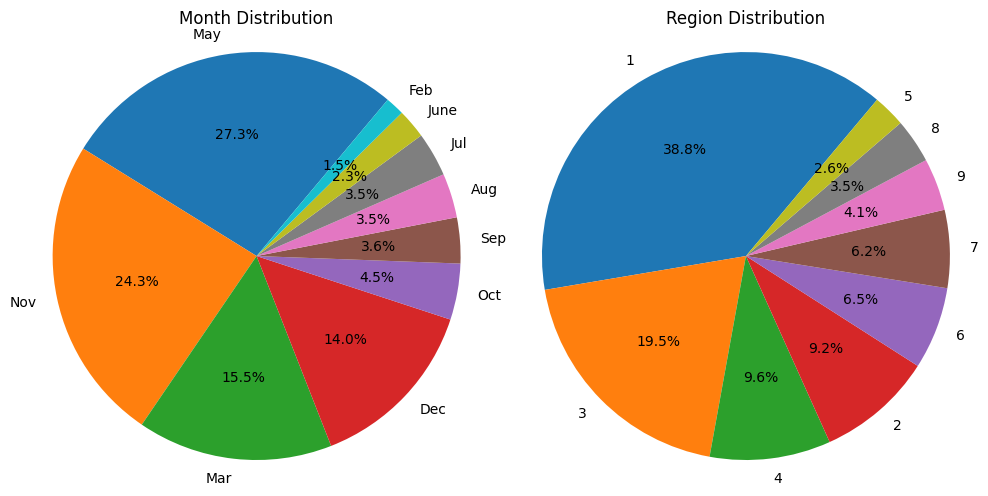

In [103]:

import pandas as pd
import matplotlib.pyplot as plt



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Pie chart for month
axes[0].pie(df['Month'].value_counts(), autopct='%1.1f%%', startangle=50,  labels=df['Month'].value_counts().index)
axes[0].set_title('Month Distribution')
axes[0].axis('equal')

# Pie chart for region
axes[1].pie(df['Region'].value_counts(), autopct='%1.1f%%', startangle=50,  labels=df['Region'].value_counts().index)
# Regions are unfortunately anonymously integer encoded
axes[1].set_title('Region Distribution')
axes[1].axis('equal')

plt.tight_layout()
plt.show()


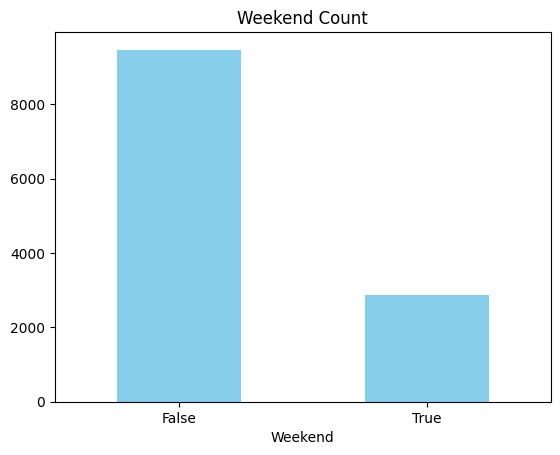

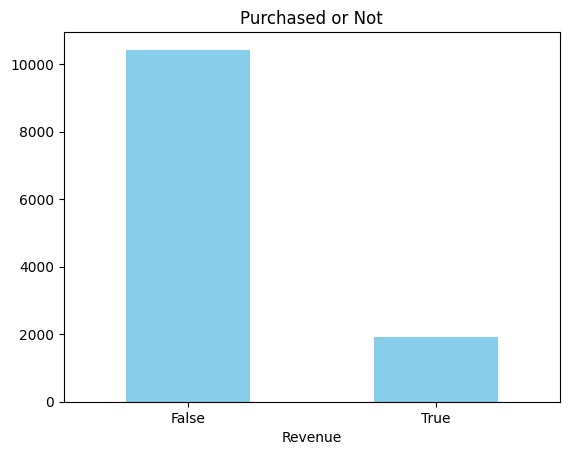

<Axes: title={'center': 'Visitor Type Count'}, xlabel='VisitorType'>

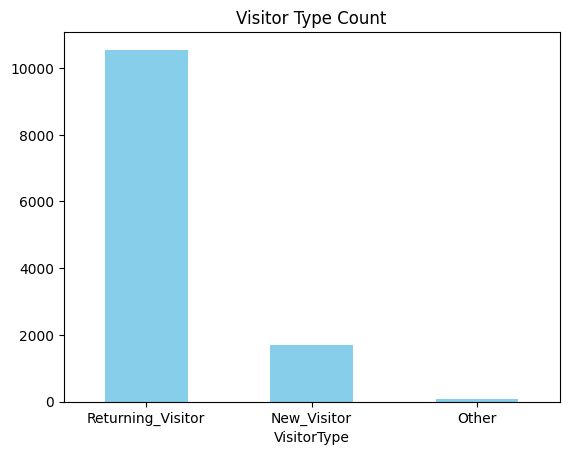

In [104]:
# bar charts for weekend, revenue and Visitor type
df['Weekend'].value_counts().plot(
kind='bar',
rot=0,
color='skyblue',
title='Weekend Count'
)
plt.show()

df['Revenue'].value_counts().plot(
kind='bar',
rot=0,
color='skyblue',
title='Purchased or Not'
)
plt.show()

df['VisitorType'].value_counts().plot(
kind='bar',
rot=0,
color='skyblue',
title='Visitor Type Count'
)



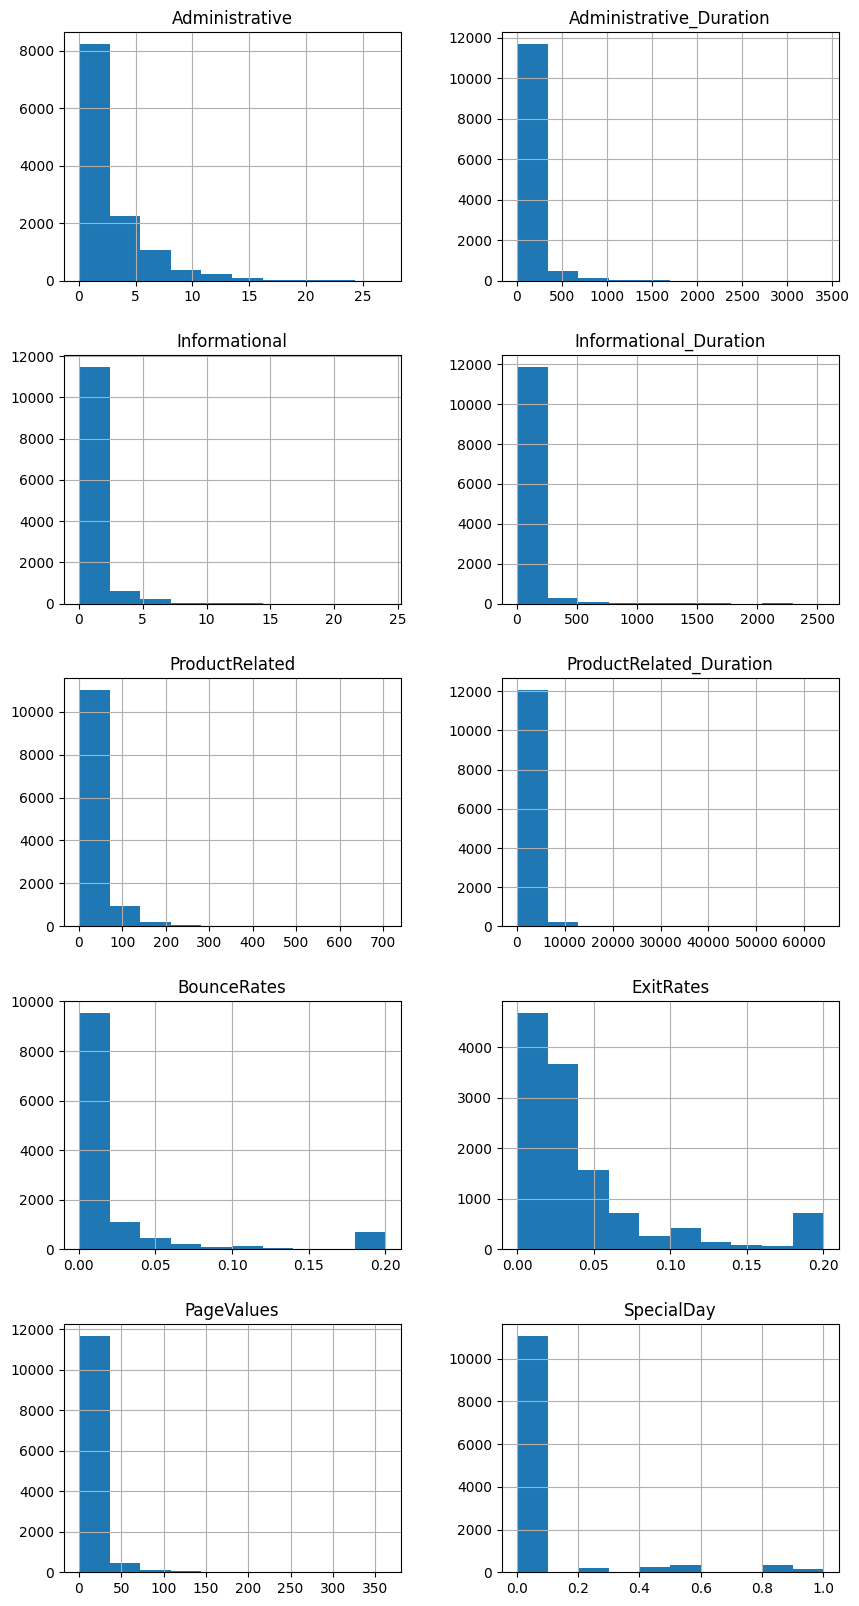

In [105]:
# Histograms for numerical data
df.hist(figsize=(10,20), column=numerical_features, layout=(5,2))
plt.show()

In [106]:
# Applying Preprocessing techniques
# checking for missing values
display(df.isnull().sum())
#no missing values hence imputation is skipped

display(df.duplicated().sum())
# checking for duplicated data
display(df[df.duplicated()].head())

# Our decision is to drop the duplicate rows as there are only a few (125 records) of them
# and given the meaning of the features it seems less plausible that two users have the exact same set
# of values across all features
df_clean = df.drop_duplicates()
df_clean.info()


# checking for outliers
for feature in numerical_features:
  Q1 = df_clean[feature].quantile(0.25)
  Q3 = df_clean[feature].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
  print(f"Outliers in {feature}:")
  display(outliers)
# we have decided not to remove any outliers as they could represent genuine
# and they constitute a major number of records for each feature





,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


np.int64(125)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False


<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
62,12,279.416667,0,0.000000,42,1553.583333,0.009000,0.019667,38.308493,0.0,Feb,1,1,3,2,Returning_Visitor,False,False
248,16,155.631313,0,0.000000,32,908.013456,0.005000,0.018053,4.368516,0.0,Mar,2,2,3,2,Returning_Visitor,False,True
282,13,1249.809524,4,205.000000,36,1626.625433,0.010638,0.026186,6.831792,0.0,Mar,3,2,2,3,Returning_Visitor,False,False
288,11,215.523809,1,70.000000,87,3037.499952,0.002151,0.007722,0.000000,0.0,Mar,2,2,5,1,Returning_Visitor,False,False
478,13,315.966667,1,0.000000,15,406.575000,0.019048,0.032381,0.000000,0.0,Mar,3,2,3,2,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12209,12,257.750000,0,0.000000,3,97.500000,0.000000,0.038462,0.000000,0.0,Dec,3,2,4,8,Returning_Visitor,False,True
12221,12,317.628205,2,256.500000,81,3675.940705,0.006742,0.017421,11.622885,0.0,Dec,2,2,1,10,Returning_Visitor,True,True
12233,13,399.750000,3,47.750000,61,1458.993056,0.001786,0.016552,17.497219,0.0,Nov,1,1,1,2,New_Visitor,False,False
12236,12,219.274359,4,857.166667,107,2640.135697,0.000000,0.015490,6.479206,0.0,Nov,1,2,1,2,Returning_Visitor,True,True


...

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200,0.20,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12277,0,0.0,0,0.0,2,40.500000,0.000,0.10,0.0,0.0,Dec,1,1,3,3,Other,False,False
12290,0,0.0,0,0.0,20,1008.500000,0.080,0.12,0.0,0.0,Dec,2,2,3,1,Returning_Visitor,True,False
12292,0,0.0,0,0.0,8,189.500000,0.075,0.10,0.0,0.0,Dec,3,2,1,13,Returning_Visitor,False,False
12301,0,0.0,0,0.0,2,0.000000,0.200,0.20,0.0,0.0,Nov,1,1,4,1,Returning_Visitor,False,False


Outliers in PageValues:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
29,1,6.000000,1,0.00,45,1582.750000,0.043478,0.050821,54.179764,0.4,Feb,3,2,1,1,Returning_Visitor,False,False
57,4,56.000000,2,120.00,36,998.741667,0.000000,0.014736,19.447079,0.2,Feb,2,2,4,1,Returning_Visitor,False,False
62,12,279.416667,0,0.00,42,1553.583333,0.009000,0.019667,38.308493,0.0,Feb,1,1,3,2,Returning_Visitor,False,False
65,3,87.833333,0,0.00,27,798.333333,0.000000,0.012644,22.916036,0.8,Feb,2,2,3,1,Returning_Visitor,False,True
76,10,1005.666667,0,0.00,36,2111.341667,0.004348,0.014493,11.439412,0.0,Feb,2,6,1,2,Returning_Visitor,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,2,305.125000,3,368.25,27,1121.250000,0.020000,0.042857,39.519807,0.0,Dec,3,2,1,2,Returning_Visitor,False,False
12312,7,150.357143,1,9.00,221,11431.001240,0.011149,0.021904,1.582473,0.0,Nov,2,5,1,2,Returning_Visitor,True,True
12313,3,16.000000,3,86.00,15,2773.500000,0.000000,0.030000,78.811725,0.0,Dec,2,2,1,2,Returning_Visitor,False,True
12319,0,0.000000,0,0.00,21,1128.583333,0.000000,0.013043,3.685401,0.0,Dec,2,2,1,2,Returning_Visitor,False,False


Outliers in SpecialDay:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.000000,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.000000,0.4,Feb,2,4,1,2,Returning_Visitor,False,False
11,0,0.0,0,0.0,16,407.750000,0.018750,0.025833,0.000000,0.4,Feb,1,1,4,3,Returning_Visitor,False,False
20,0,0.0,0,0.0,8,136.166667,0.000000,0.008333,0.000000,1.0,Feb,2,2,5,1,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1,149.5,0,0.0,32,1562.333333,0.038710,0.062581,7.636645,0.2,May,2,2,3,2,Returning_Visitor,False,False
5448,3,35.5,0,0.0,14,241.769231,0.000000,0.020417,0.000000,0.6,May,3,2,3,2,Returning_Visitor,False,False
5450,2,42.0,0,0.0,17,275.702381,0.040000,0.060000,0.000000,0.6,May,3,2,8,2,Returning_Visitor,False,False
5453,2,76.0,1,79.0,35,2072.666667,0.007207,0.031081,8.100000,0.8,May,2,4,7,2,Returning_Visitor,False,False


In [107]:
from sklearn.preprocessing import OneHotEncoder
cat_features = [c for c in cat_features if c != 'Weekend']
# one hot encoding of categorical features
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df_clean[cat_features])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(cat_features),
    index=df_clean.index
)

# drop the original categorical columns and join the encoded ones
df_final = pd.concat([df_clean.drop(columns=cat_features), encoded_df], axis=1)

# checks
print(df_clean.shape, '->', df_final.shape)
# binary encode label and visitor returning type
bool_cols = ['Weekend', 'Revenue']
df_final[bool_cols] = df_final[bool_cols].astype(int)
display(df_final.head())



(12205, 18) -> (12205, 75)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Before log transformation:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


After log transformation:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
12325,1.386294,4.983607,0.0,0.0,3.988984,7.487057,0.007117,0.028617,2.583372,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12326,0.000000,0.000000,0.0,0.0,1.791759,6.145794,0.000000,0.021109,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12327,0.000000,0.000000,0.0,0.0,1.945910,5.221706,0.080043,0.083115,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12328,1.609438,4.330733,0.0,0.0,2.772589,5.849325,0.000000,0.020834,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12329,0.000000,0.000000,0.0,0.0,1.386294,3.102342,0.000000,0.064539,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


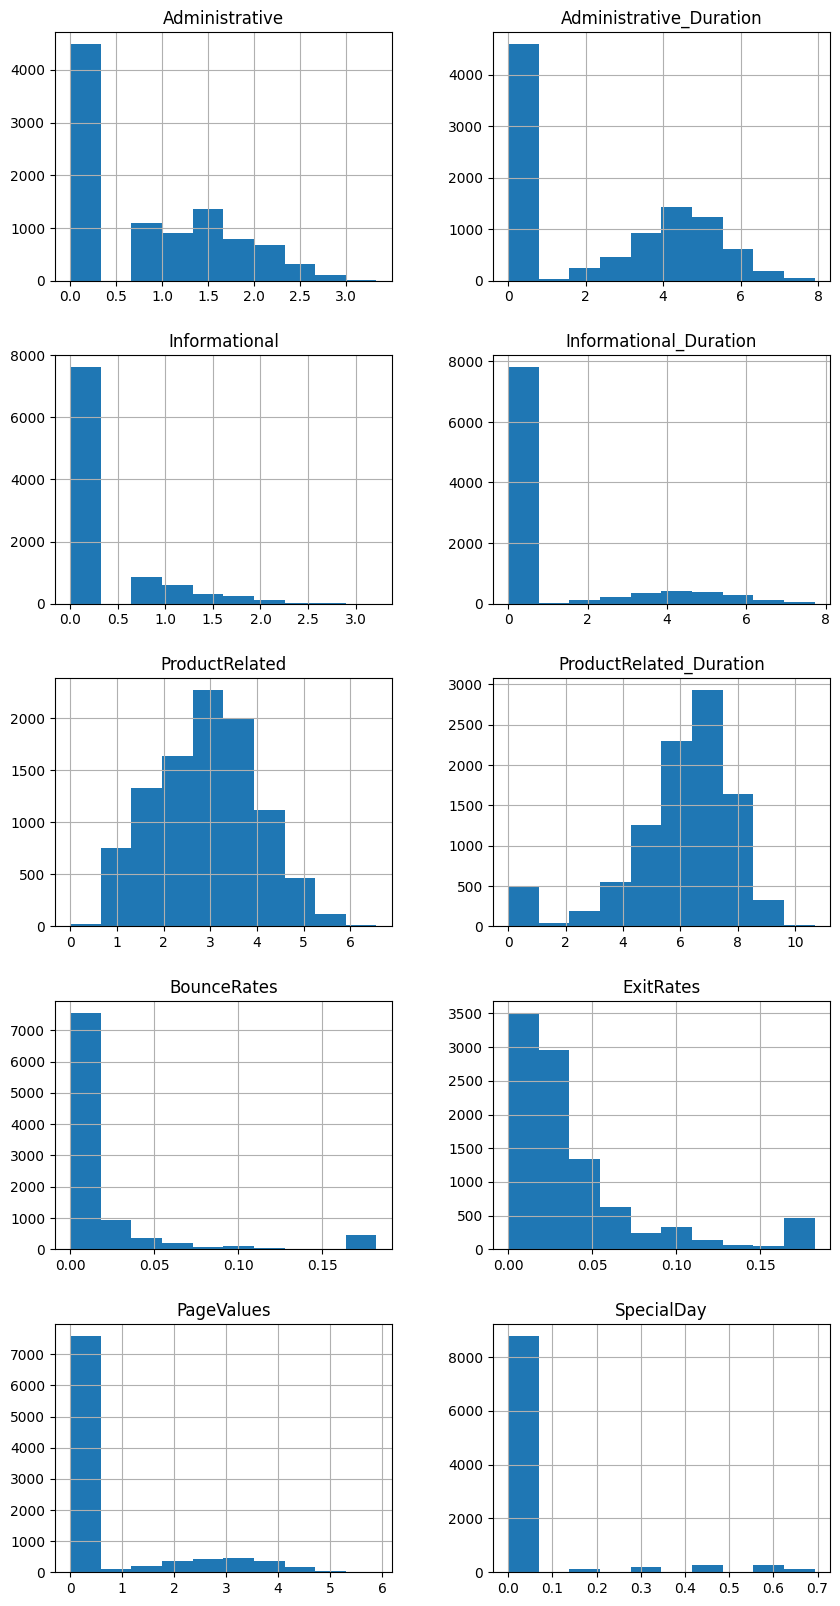

Scaled Training Data:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
12086,-0.935670,-0.989312,-0.485484,-0.472178,-0.870660,-0.983411,0.328247,0.588828,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5272,1.322981,0.867597,0.901436,1.164295,-0.383550,-0.142488,-0.464300,-0.857922,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5475,0.339508,0.868122,2.288355,2.700757,0.583848,0.456142,-0.011292,0.064020,0.915532,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
874,0.673426,0.780339,-0.485484,-0.472178,0.609307,0.598520,-0.464300,-0.764439,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7357,-0.131122,0.709474,3.408091,2.929829,0.164238,0.360004,-0.464300,-0.936576,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Scaled Testing Data:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
8420,-0.93567,-0.989312,-0.485484,-0.472178,0.078102,0.637583,0.163541,-0.001600,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2679,-0.93567,-0.989312,-0.485484,-0.472178,0.242873,-0.431265,1.551077,1.159917,-0.498613,2.877332,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11378,-0.93567,-0.989312,-0.485484,-0.472178,-2.002828,-3.095450,3.942506,3.372698,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7733,-0.93567,-0.989312,-0.485484,-0.472178,-2.002828,-3.095450,3.942506,3.372698,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8431,-0.93567,-0.989312,-0.485484,-0.472178,0.992323,0.799697,-0.374945,-0.560252,-0.498613,-0.313394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


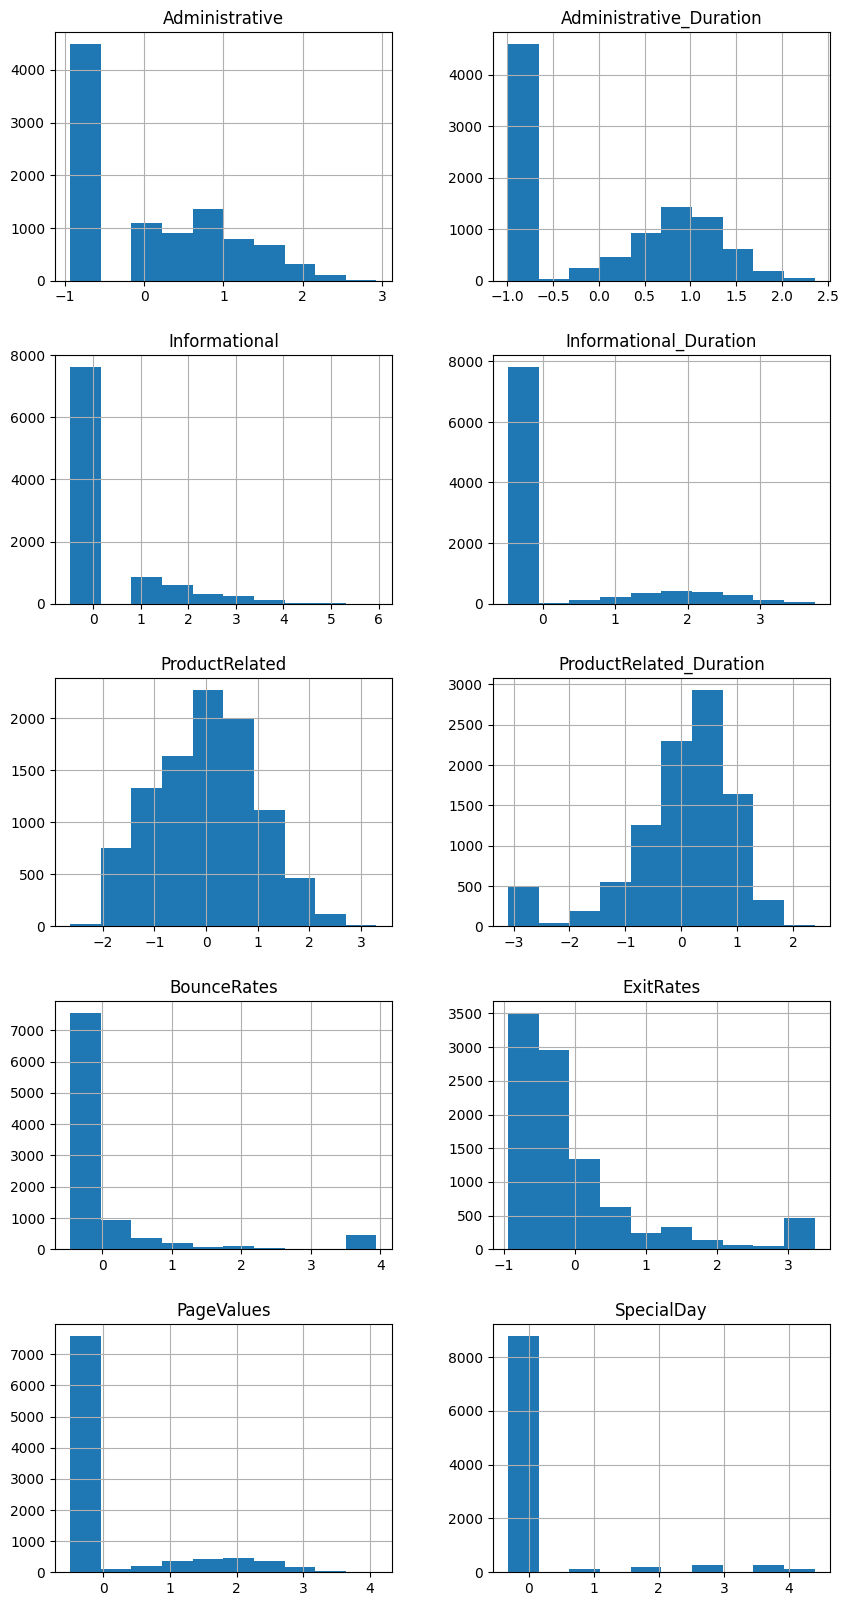

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_final.drop(columns=['Revenue'])
y = df_final['Revenue']

print("Before log transformation:")
display(X.tail())

# Apply log transformation to numerical features c
X = X.copy()
X[numerical_features] = np.log1p(X[numerical_features])

print("After log transformation:")
display(X.tail())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Plot histograms from the training set
X_train.hist(figsize=(10, 20), column=numerical_features, layout=(5, 2))
plt.show()


X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform numerical features
scaler = StandardScaler()

# Fit on TRAIN, transform TRAIN
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Transform TEST using the TRAIN scaler
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# Check final outputs
print("Scaled Training Data:")
display(X_train_scaled.tail())

print("Scaled Testing Data:")
display(X_test_scaled.tail())

# Histogram of scaled training data
X_train_scaled.hist(figsize=(10, 20), column=numerical_features, layout=(5, 2))
plt.show()
